In [80]:
import pytorch3d.io
import pytorch3d.renderer
import pytorch3d.structures
import matplotlib.pyplot as plt
import torch
from starter.utils import get_mesh_renderer
import numpy

In [32]:
verts, faces, aux = pytorch3d.io.load_obj("data/cow.obj")

In [33]:
# find z-min and z-max
z_min = min(verts, key=lambda vert: vert[2])[2]
z_max = max(verts, key=lambda vert: vert[2])[2]
print(z_min, z_max)

tensor(-0.6689) tensor(1.0490)


In [75]:
# find color for each vert
color1 = torch.Tensor([1, 0, 1])
color2 = torch.Tensor([0, 1, 0])

colors = []

for vert in verts:
    x, y, z = vert
    alpha = (z - z_min) / (z_max - z_min)
    color = alpha * color2 + (1 - alpha) * color1
    colors.append(color)


In [76]:
# apply to texture
textures = pytorch3d.renderer.TexturesVertex(torch.stack(colors).unsqueeze(0))

In [77]:
# camera, light, renderer

R, T = pytorch3d.renderer.look_at_view_transform(dist=5, elev=0, azim=90.0)

lights = pytorch3d.renderer.DirectionalLights()
cameras = pytorch3d.renderer.FoVPerspectiveCameras(R=R, T=T, fov=60)

In [78]:
# construct mesh

mesh = pytorch3d.structures.Meshes(verts=verts.unsqueeze(0).cpu(), faces=torch.unsqueeze(faces.verts_idx, 0), textures=textures)
rend = get_mesh_renderer(image_size=500, device='cpu')(mesh, cameras=cameras, lights=lights)

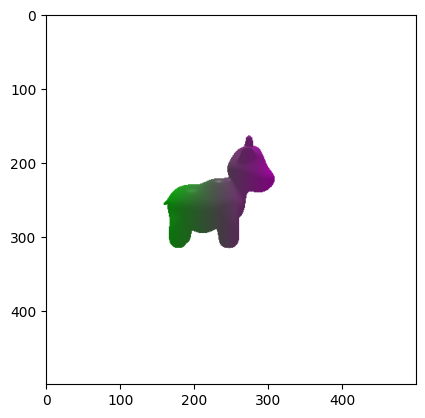

In [79]:
# render image
plt.plot(figsize=(10, 10))
plt.imshow(rend[0, ..., :3])

In [82]:
# export anim
import imageio
frames = []

for azimuth in range(0, 360, 5):
    # camera, light, renderer
    
    R, T = pytorch3d.renderer.look_at_view_transform(dist=5, elev=0, azim=azimuth)
    
    lights = pytorch3d.renderer.DirectionalLights()
    cameras = pytorch3d.renderer.FoVPerspectiveCameras(R=R, T=T, fov=60)
    
    # construct mesh
    
    mesh = pytorch3d.structures.Meshes(verts=verts.unsqueeze(0).cpu(), faces=torch.unsqueeze(faces.verts_idx, 0), textures=textures)
    rend = get_mesh_renderer(image_size=500, device='cpu')(mesh, cameras=cameras, lights=lights)

    frames.append( (rend[0, ..., :3].numpy() * 255).astype(numpy.uint8) )

imageio.mimsave("gif_cow_retextured.gif", frames, duration=1000/25, loop=0)